In [1]:
import random
from typing import Sequence

import matplotlib.pyplot as plt
import numpy
import pandas
import seaborn
from deap import algorithms
from deap import base, creator, tools
from scipy.stats import pointbiserialr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PREPARATION

In [2]:
# Define random seeds for reproducibility
SEED: int = 42
random.seed(SEED)
numpy.random.seed(SEED)

In [3]:
CSV_PATH: str = "diabetes_preprocessed.csv"
TARGET_COLUMN: str = "Outcome"

# Read CSV file
df: pandas.DataFrame = pandas.read_csv(CSV_PATH)

y: pandas.Series = df[TARGET_COLUMN]
X: pandas.DataFrame = df.drop(columns=[TARGET_COLUMN])

feature_names: list[str] = list(X.columns)

In [4]:
# Split data into training and validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=SEED,
    stratify=y
)

# 20% val, 20% test
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

# Scale dataset based on train set
scaler: StandardScaler = StandardScaler()
X_train_scaled: numpy.ndarray = scaler.fit_transform(X_train)
X_validation_scaled: numpy.ndarray = scaler.transform(X_validation)
X_test_scaled: numpy.ndarray = scaler.transform(X_test)

In [5]:
# Calculate Point-biserial correlation coefficients (target value is binary and the input variables are continuous)
point_biserial_corr: pandas.Series = pandas.Series(dtype=float)

for column in X_train.columns:
    correlation, _ = pointbiserialr(y_train, X_train[column])
    point_biserial_corr[column] = correlation

# MULTI OBJECTIVE

In [6]:
def coefficient_sign_score(coefficients: dict[str, float], corr_series: pandas.Series,
                           zero_tol: float = 1e-12) -> float:
    """
    Calculate the coefficient sign consistency score.

    Parameters:
        coefficients (dict[str, float]): Coefficients of the model.
        corr_series (pandas.Series): Pearson correlation coefficients.
        zero_tol (float): Tolerance for considering a value as zero.

    Returns:
        float: Coefficient sign consistency score.
    """
    penalties: float = 0.0
    total: int = len(coefficients)

    if total == 0:
        return 0.0

    for feature_name, coefficient in coefficients.items():
        correlation: float = corr_series[feature_name]

        if numpy.isnan(correlation):
            penalties += 1.0
            continue

        check: float = correlation * coefficient

        if numpy.isclose(check, 0.0, atol=zero_tol) or check < 0:
            penalties += 1.0

    return 1.0 - penalties / total

In [7]:
def evaluate_multi(individual: Sequence[int]) -> tuple[float, float]:
    if sum(individual) == 0:
        return 0.0, 0.0

    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]

    X_train_reduced: numpy.ndarray = X_train_scaled[:, cols]
    X_validation_reduced: numpy.ndarray = X_validation_scaled[:, cols]

    model: LogisticRegression = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED
    )

    model.fit(X_train_reduced, y_train)

    probs: numpy.ndarray = model.predict_proba(X_validation_reduced)[:, 1]

    # Calculate PR-AUC on validation set
    pr_auc: float = average_precision_score(y_validation, probs)

    # Calculate coefficient sign consistency score
    coef_dict: dict[str, float] = {
        feature_names[i]: model.coef_[0][j]
        for j, i in enumerate(cols)
    }
    sign_score: float = coefficient_sign_score(coef_dict, point_biserial_corr)

    return pr_auc, sign_score

In [8]:
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, 1.0))

if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox: base.Toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual,
    toolbox.attr_bool,
    n=X_train.shape[1],
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_multi)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / len(X_train.columns))
toolbox.register("select", tools.selNSGA2)

In [9]:
# Bigger population -> bigger search space
POP_SIZE: int = 200
# Bigger generation number -> bigger convergence
NGEN: int = 150
# Crossing probability
CXPB: float = 0.5
# Mutation probability
MUTPB: float = 0.2

pop: list[creator.Individual] = toolbox.population(n=POP_SIZE)

# Initial evaluation
invalid: list[creator.Individual] = [ind for ind in pop if not ind.fitness.valid]
fitnesses: list[tuple[float, float]] = list(map(toolbox.evaluate, invalid))
for ind, fit in zip(invalid, fitnesses):
    ind.fitness.values = fit

# Crowding distance assignment
pop: list[creator.Individual] = toolbox.select(pop, len(pop))  # crowding assignment

# Pareto archive
hof: tools.ParetoFront = tools.ParetoFront()
hof.update(pop)

# Genetic algorithm
for gen in range(NGEN):
    # Binary tournament selection (NSGA-II)
    offspring: list[creator.Individual] = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # Crossover
    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() <= CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values
            del ind2.fitness.values

    # Mutation
    for mutant in offspring:
        if random.random() <= MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Fitness evaluation
    invalid: list[creator.Individual] = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses: list[tuple[float, float]] = list(map(toolbox.evaluate, invalid))
    for ind, fit in zip(invalid, fitnesses):
        ind.fitness.values = fit

    # Combine parents + offspring
    combined: list[creator.Individual] = pop + offspring

    # NSGA-II survival selection
    pop: list[creator.Individual] = toolbox.select(pop + offspring, POP_SIZE)

    # Update global Pareto archive
    hof.update(pop)

    print(f"Generation {gen + 1} done | Pareto size: {len(hof)}")

Generation 1 done | Pareto size: 4
Generation 2 done | Pareto size: 4
Generation 3 done | Pareto size: 6
Generation 4 done | Pareto size: 6
Generation 5 done | Pareto size: 6
Generation 6 done | Pareto size: 6
Generation 7 done | Pareto size: 6
Generation 8 done | Pareto size: 7
Generation 9 done | Pareto size: 7
Generation 10 done | Pareto size: 7
Generation 11 done | Pareto size: 7
Generation 12 done | Pareto size: 7
Generation 13 done | Pareto size: 7
Generation 14 done | Pareto size: 7
Generation 15 done | Pareto size: 7
Generation 16 done | Pareto size: 7
Generation 17 done | Pareto size: 7
Generation 18 done | Pareto size: 7
Generation 19 done | Pareto size: 7
Generation 20 done | Pareto size: 7
Generation 21 done | Pareto size: 7
Generation 22 done | Pareto size: 7
Generation 23 done | Pareto size: 7
Generation 24 done | Pareto size: 7
Generation 25 done | Pareto size: 7
Generation 26 done | Pareto size: 7
Generation 27 done | Pareto size: 7
Generation 28 done | Pareto size: 7
G

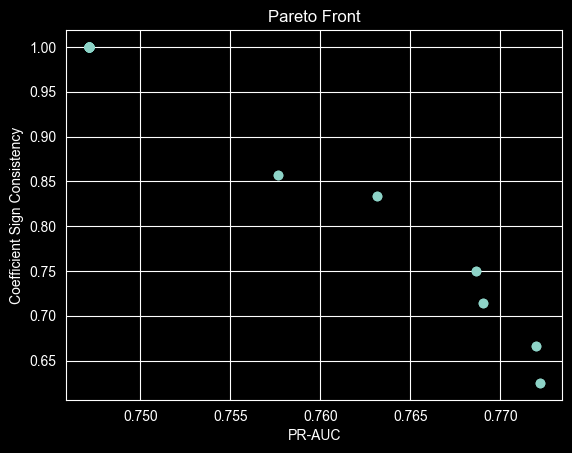

In [10]:
pareto: list[creator.Individual] = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]

pr_values: list[float] = [ind.fitness.values[0] for ind in pareto]
sign_values: list[float] = [ind.fitness.values[1] for ind in pareto]

plt.scatter(pr_values, sign_values)
plt.xlabel("PR-AUC")
plt.ylabel("Coefficient Sign Consistency")
plt.title("Pareto Front")
plt.show()

In [11]:
# Get the best individual model based on Knee-point algorithm
points: numpy.ndarray = numpy.array([ind.fitness.values for ind in pareto])

#  Points on the knee of the Pareto front
p1: numpy.ndarray = points[numpy.argmax(points[:, 0])]
p2: numpy.ndarray = points[numpy.argmax(points[:, 1])]

# Only one point
if numpy.allclose(p1, p2):
    best_index: int = 0
else:
    #  Vector of the line
    line_vector: numpy.ndarray = p2 - p1
    line_vector = line_vector / numpy.linalg.norm(line_vector)

    #  Distance calculation
    distances: list[float] = []
    for p in points:
        vector: numpy.ndarray = p - p1
        projection: numpy.ndarray = numpy.dot(vector, line_vector) * line_vector
        orthogonal: numpy.ndarray = vector - projection
        distances.append(float(numpy.linalg.norm(orthogonal)))

    best_index: int = int(numpy.argmax(distances))

best_individual: creator.Individual = pareto[best_index]
best_cols: numpy.ndarray = numpy.where(numpy.array(best_individual) == 1)[0]

print(f"Best individual PR-AUC: {best_individual.fitness.values[0]}")
print(f"Best individual sign consistency: {best_individual.fitness.values[1]}")

selected_feature_names: list[str] = [feature_names[i] for i in best_cols]
selected_feature_names.sort()
print("Selected features:", selected_feature_names)

Best individual PR-AUC: 0.7631679756445782
Best individual sign consistency: 0.8333333333333334
Selected features: ['Age', 'BMI', 'Glucose', 'ln_age', 'ln_diabetes_pedigree_function', 'ln_pregnancies']


In [12]:
# Calculate the final results on the test set
X_train_reduced: numpy.ndarray = X_train_scaled[:, best_cols]
X_test_reduced: numpy.ndarray = X_test_scaled[:, best_cols]

final_model: LogisticRegression = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

final_model.fit(X_train_reduced, y_train)

test_probs: numpy.ndarray = final_model.predict_proba(X_test_reduced)[:, 1]
test_pr_auc: float = average_precision_score(y_test, test_probs)

print("Final PR-AUC on test set:", test_pr_auc)

Final PR-AUC on test set: 0.7136119486536848


Best threshold: 0.2758997182511551
Sensitivity on validation set (with new threshold): 0.9444444444444444
Specificity on validation set (with new threshold): 0.75
Sensitivity on test set (with new threshold): 0.8113207547169812
Specificity on test set (with new threshold): 0.6435643564356436


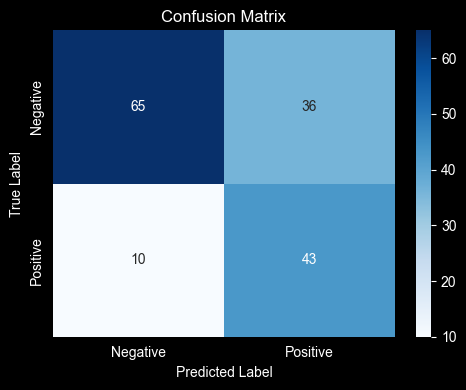

In [13]:
# Calculate the optimal specificity and sensitivity scores and threshold
X_validation_reduced: numpy.ndarray = X_validation_scaled[:, best_cols]
validation_probs: numpy.ndarray = final_model.predict_proba(X_validation_reduced)[:, 1]

fpr, tpr, thresholds = roc_curve(y_validation, validation_probs)

specificity: numpy.ndarray = 1 - fpr
sensitivity: numpy.ndarray = tpr

# Youden index
youden_index: numpy.ndarray = sensitivity + specificity - 1
best_idx: int = int(numpy.argmax(youden_index))

best_threshold: float = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Sensitivity on validation set (with new threshold):", sensitivity[best_idx])
print("Specificity on validation set (with new threshold):", specificity[best_idx])

# Calculate the final results with the best threshold on the test set
y_pred: numpy.ndarray = (test_probs >= best_threshold).astype(int)
cm: numpy.ndarray = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity: float = tp / (tp + fn)
specificity: float = tn / (tn + fp)
print("Sensitivity on test set (with new threshold):", sensitivity)
print("Specificity on test set (with new threshold):", specificity)

labels: list[str] = ["Negative", "Positive"]  # Adjust as needed
plt.figure(figsize=(5, 4))
seaborn.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()

# SINGLE OBJECTIVE

In [14]:
# Reset random seeds for reproducibility
random.seed(SEED)
numpy.random.seed(SEED)

In [15]:
def evaluate_single(individual: Sequence[int]) -> tuple[float]:
    if sum(individual) == 0:
        return (0.0,)

    cols: list[int] = [i for i, bit in enumerate(individual) if bit]

    X_train_reduced: numpy.ndarray = X_train_scaled[:, cols]
    X_validation_reduced: numpy.ndarray = X_validation_scaled[:, cols]

    model: LogisticRegression = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED
    )

    model.fit(X_train_reduced, y_train)

    probs: numpy.ndarray = model.predict_proba(X_validation_reduced)[:, 1]
    pr_auc: float = average_precision_score(y_validation, probs)

    return (pr_auc,)

In [16]:
if "FitnessSingle" not in creator.__dict__:
    creator.create("FitnessSingle", base.Fitness, weights=(1.0,))

if "IndividualSingle" not in creator.__dict__:
    creator.create("IndividualSingle", list, fitness=creator.FitnessSingle)

In [17]:
toolbox: base.Toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.IndividualSingle,
    toolbox.attr_bool,
    n=X_train.shape[1],
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_single)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / len(X_train.columns))

toolbox.register("select", tools.selTournament, tournsize=3)

pop: list[creator.IndividualSingle] = toolbox.population(n=POP_SIZE)
hof: tools.HallOfFame = tools.HallOfFame(1)

stats: tools.Statistics = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)

pop, logbook = algorithms.eaSimple(
    pop,
    toolbox,
    cxpb=0.5,
    mutpb=0.2,
    ngen=NGEN,
    stats=stats,
    halloffame=hof,
    verbose=True
)

best_individual: creator.IndividualSingle = hof[0]
best_cols: list[int] = [i for i, bit in enumerate(best_individual) if bit == 1]

selected_feature_names: list[str] = [feature_names[i] for i in best_cols]
selected_feature_names.sort()
print("Selected features:", selected_feature_names)

gen	nevals	max     
0  	200   	0.764138
1  	118   	0.765217
2  	118   	0.765061
3  	110   	0.771966
4  	116   	0.772187
5  	115   	0.772187
6  	122   	0.772187
7  	133   	0.772187
8  	113   	0.772187
9  	116   	0.772187
10 	116   	0.772187
11 	118   	0.772187
12 	139   	0.772187
13 	107   	0.772187
14 	110   	0.772187
15 	106   	0.772187
16 	128   	0.772187
17 	127   	0.772187
18 	109   	0.772187
19 	115   	0.772187
20 	130   	0.772187
21 	132   	0.772187
22 	133   	0.772187
23 	108   	0.772187
24 	117   	0.772187
25 	122   	0.772187
26 	110   	0.772187
27 	127   	0.772187
28 	115   	0.772187
29 	96    	0.772187
30 	125   	0.772187
31 	115   	0.772187
32 	110   	0.772187
33 	114   	0.772187
34 	129   	0.772187
35 	131   	0.772187
36 	127   	0.772187
37 	123   	0.772187
38 	114   	0.772187
39 	107   	0.772187
40 	123   	0.772187
41 	127   	0.772187
42 	122   	0.772187
43 	114   	0.772187
44 	126   	0.772187
45 	116   	0.772187
46 	109   	0.772187
47 	116   	0.772187
48 	120   	0.772187


In [18]:
# Calculate the final results on the test set
X_train_reduced: numpy.ndarray = X_train_scaled[:, best_cols]
X_test_reduced: numpy.ndarray = X_test_scaled[:, best_cols]

final_model: LogisticRegression = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

final_model.fit(X_train_reduced, y_train)

test_probs: numpy.ndarray = final_model.predict_proba(X_test_reduced)[:, 1]
test_pr_auc: float = average_precision_score(y_test, test_probs)

print("Final PR-AUC on test set:", test_pr_auc)

Final PR-AUC on test set: 0.7145949144481567


Best threshold: 0.27904007989059987
Sensitivity on validation set (with new threshold): 0.9444444444444444
Specificity on validation set (with new threshold): 0.75
Sensitivity on test set (with new threshold): 0.8301886792452831
Specificity on test set (with new threshold): 0.6534653465346535


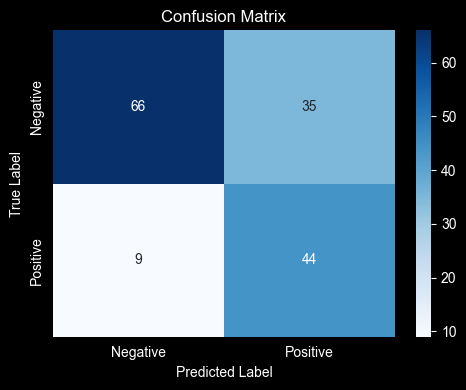

In [19]:
# Calculate the optimal specificity and sensitivity scores and threshold
X_validation_reduced: numpy.ndarray = X_validation_scaled[:, best_cols]
validation_probs: numpy.ndarray = final_model.predict_proba(X_validation_reduced)[:, 1]

fpr, tpr, thresholds = roc_curve(y_validation, validation_probs)

specificity: numpy.ndarray = 1 - fpr
sensitivity: numpy.ndarray = tpr

# Youden index
youden_index: numpy.ndarray = sensitivity + specificity - 1
best_idx: int = int(numpy.argmax(youden_index))

best_threshold: float = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Sensitivity on validation set (with new threshold):", sensitivity[best_idx])
print("Specificity on validation set (with new threshold):", specificity[best_idx])

# Calculate the final results with the best threshold on the test set
y_pred: numpy.ndarray = (test_probs >= best_threshold).astype(int)
cm: numpy.ndarray = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity: float = tp / (tp + fn)
specificity: float = tn / (tn + fp)
print("Sensitivity on test set (with new threshold):", sensitivity)
print("Specificity on test set (with new threshold):", specificity)

labels: list[str] = ["Negative", "Positive"]  # Adjust as needed
plt.figure(figsize=(5, 4))
seaborn.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()